<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/w5n2_model_evaluation_ab_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 10-  Model Evaluation Metrics & Introduction to A/B Testing
### Statistics & Quantitative Methods for Data Science

Once a model is built, how do we know if it's any good? And once a business change is proposed (a new button color, a new pricing plan), how do we know if it actually worked? Both questions come back to statistics.

**This notebook:**
1. Train a simple classifier (logistic regression) on Titanic
2. Classification metrics: confusion matrix, accuracy, precision, recall, F1
3. ROC curve & AUC
4. Regression metrics: MAE, MSE, RMSE, R²
5. Cross-validation
6. A/B testing: the two-proportion z-test
7. Sample size & power for A/B tests
8. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Training a simple classifier

We'll predict `survived` from a handful of features, using logistic regression — the classification cousin of the linear regression from Week 4.

In [ ]:
features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df = titanic.dropna(subset=features + ['survived']).copy()
X, y = df[features], df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of survival

print(f"Test set size: {len(y_test)}")
print(f"Predicted survival rate: {y_pred.mean():.3f}  |  Actual: {y_test.mean():.3f}")

Test set size: 179
Predicted survival rate: 0.302  |  Actual: 0.408


---
# 2. Classification metrics

The **confusion matrix** breaks every prediction into 4 buckets — the exact same true-positive/false-positive language as Week 5's Bayes'-theorem medical test example:

| | Predicted died | Predicted survived |
|---|---|---|
| **Actually died** | True Negative | False Positive |
| **Actually survived** | False Negative | True Positive |

- **Accuracy** = (TP+TN) / total — misleading under class imbalance (recall Week 5, Class 1)
- **Precision** = TP / (TP+FP) — of everyone we predicted survived, how many really did?
- **Recall** = TP / (TP+FN) — of everyone who really survived, how many did we catch?
- **F1** = harmonic mean of precision and recall — balances the two

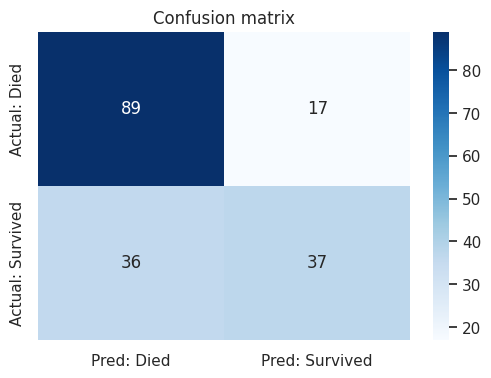

Accuracy:  0.704
Precision: 0.685
Recall:    0.507
F1 score:  0.583


In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Died', 'Pred: Survived'], yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title('Confusion matrix'); plt.show()

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

### The precision/recall trade-off

Logistic regression outputs a *probability*; we chose 0.5 as the cutoff to call something "survived." Moving that threshold trades precision against recall.

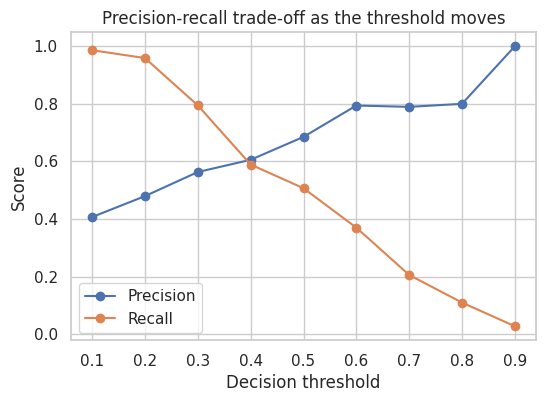

In [ ]:
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls = [], []
for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, preds_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_t, zero_division=0))

plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')
plt.xlabel('Decision threshold'); plt.ylabel('Score'); plt.legend()
plt.title('Precision-recall trade-off as the threshold moves')
plt.show()

---
# 3. ROC curve & AUC

The **ROC curve** plots the true positive rate against the false positive rate across *every possible threshold* at once. **AUC** (area under the curve) summarizes it in one number: 0.5 = random guessing, 1.0 = perfect separation.

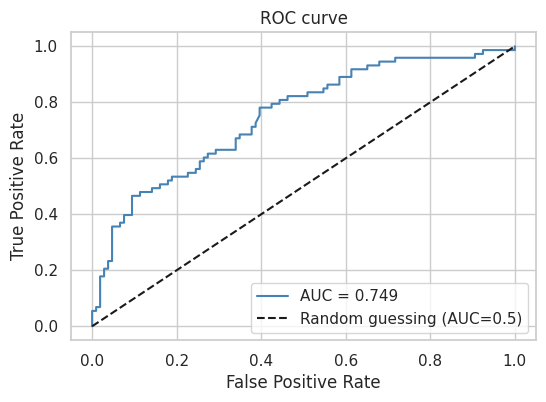

In [ ]:
fpr, tpr, thresh = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--', label='Random guessing (AUC=0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curve'); plt.legend()
plt.show()

---
# 4. Regression metrics

For a *continuous* prediction target (Week 4's regression), we use different metrics. Let's predict `fare` from the same features.

In [ ]:
reg_features = ['pclass', 'age', 'sibsp', 'parch']
df_reg = titanic.dropna(subset=reg_features + ['fare']).copy()
Xr, yr = df_reg[reg_features], df_reg['fare']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

reg = LinearRegression().fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print(f"MAE  = {mae:.2f}   (average absolute error, in original fare units)")
print(f"MSE  = {mse:.2f}   (penalizes large errors more heavily -- squared units)")
print(f"RMSE = {rmse:.2f}  (back in original units, still penalizes big misses more)")
print(f"R^2  = {r2:.3f}    (same R^2 from Week 4 -- proportion of variance explained, on UNSEEN test data)")

MAE  = 24.06   (average absolute error, in original fare units)
MSE  = 2842.08   (penalizes large errors more heavily -- squared units)
RMSE = 53.31  (back in original units, still penalizes big misses more)
R^2  = 0.188    (same R^2 from Week 4 -- proportion of variance explained, on UNSEEN test data)


---
# 5. Cross-validation

A single train/test split is itself a *sample* of possible splits — its score has sampling variability, exactly like any other point estimate from Week 3. **K-fold cross-validation** repeats the split K times and averages the result, giving a more stable (and honest) performance estimate, complete with a standard deviation.

In [ ]:
cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring='accuracy')
print(f"5-fold CV accuracy scores: {np.round(cv_scores, 3)}")
print(f"Mean accuracy: {cv_scores.mean():.3f}  +/- {cv_scores.std():.3f} (1 std)")
print("\n-> Reporting mean +/- std, rather than a single split's score, is a direct application of Week 3's confidence-interval thinking to model evaluation.")

5-fold CV accuracy scores: [0.608 0.699 0.727 0.72  0.69 ]
Mean accuracy: 0.689  +/- 0.043 (1 std)

-> Reporting mean +/- std, rather than a single split's score, is a direct application of Week 3's confidence-interval thinking to model evaluation.


---
# 6. A/B testing: the two-proportion z-test

**A/B testing** is hypothesis testing (Week 3) applied to business decisions: split users randomly into group A (control) and group B (treatment), measure a conversion rate in each, and test whether the difference is real or just noise.

$$z = \frac{\hat p_B - \hat p_A}{\sqrt{\hat p (1-\hat p)\left(\frac{1}{n_A}+\frac{1}{n_B}\right)}}, \quad \hat p = \frac{x_A+x_B}{n_A+n_B}$$

In [ ]:
def two_proportion_ztest(x_a, n_a, x_b, n_b):
    p_a, p_b = x_a/n_a, x_b/n_b
    p_pool = (x_a + x_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1-p_pool) * (1/n_a + 1/n_b))
    z = (p_b - p_a) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))   # two-tailed
    return z, p_val, p_a, p_b

# Simulated A/B test: does a new checkout page (B) convert better than the old one (A)?
np.random.seed(3)
n_a, n_b = 2000, 2000
x_a = np.random.binomial(n_a, 0.10)   # ~10% baseline conversion
x_b = np.random.binomial(n_b, 0.12)   # a modest true lift to 12%

z, p_val, p_a, p_b = two_proportion_ztest(x_a, n_a, x_b, n_b)
print(f"Control (A):   {x_a}/{n_a} = {p_a:.3f} conversion")
print(f"Treatment (B): {x_b}/{n_b} = {p_b:.3f} conversion")
print(f"z = {z:.3f}, p = {p_val:.4f}")
print("Reject H0: the new page significantly changes conversion." if p_val < 0.05 else "Fail to reject H0: not enough evidence of a difference.")

Control (A):   204/2000 = 0.102 conversion
Treatment (B): 238/2000 = 0.119 conversion
z = 1.715, p = 0.0864
Fail to reject H0: not enough evidence of a difference.


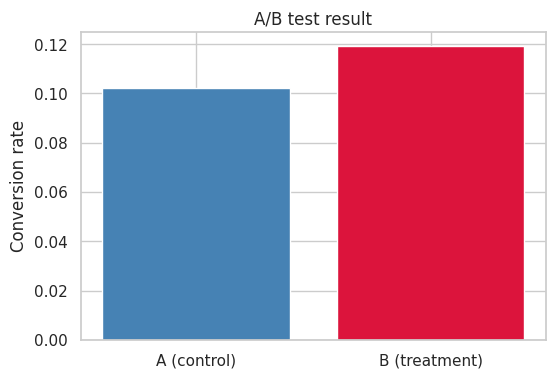

In [ ]:
plt.bar(['A (control)', 'B (treatment)'], [p_a, p_b], color=['steelblue', 'crimson'])
plt.ylabel('Conversion rate'); plt.title('A/B test result')
plt.show()

---
# 7. Sample size & power for A/B tests

Just like Week 3's margin-of-error calculation, we can work out *in advance* how many users we'd need to reliably detect a given lift, at a chosen power (probability of detecting a real effect if it exists).

In [ ]:
def ab_sample_size(p_baseline, min_detectable_effect, power=0.8, alpha=0.05):
    p1 = p_baseline
    p2 = p_baseline + min_detectable_effect
    p_avg = (p1 + p2) / 2
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_power = stats.norm.ppf(power)
    n = ((z_alpha*np.sqrt(2*p_avg*(1-p_avg)) + z_power*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2) / (p2-p1)**2
    return int(np.ceil(n))

for lift in [0.01, 0.02, 0.05]:
    n_needed = ab_sample_size(p_baseline=0.10, min_detectable_effect=lift)
    print(f"To detect a {lift:.0%} absolute lift from a 10% baseline (80% power): need n = {n_needed} PER GROUP")
print("\n-> Smaller effects need dramatically bigger samples to detect reliably -- the same 1/margin^2 scaling from Week 3.")

To detect a 1% absolute lift from a 10% baseline (80% power): need n = 14751 PER GROUP
To detect a 2% absolute lift from a 10% baseline (80% power): need n = 3841 PER GROUP
To detect a 5% absolute lift from a 10% baseline (80% power): need n = 686 PER GROUP

-> Smaller effects need dramatically bigger samples to detect reliably -- the same 1/margin^2 scaling from Week 3.


---
# 8. Exercises

1. Retrain the logistic regression using only `['pclass', 'sex_code']` (encode `sex` as 0/1 first) as features. Does accuracy improve or worsen versus the 5-feature model?
2. Compute precision and recall at threshold 0.3 and at 0.7 for the original model. Which threshold would you pick if **missing a survivor** (false negative) was the costlier mistake?
3. Fit a linear regression predicting `age` instead of `fare`, using `['pclass','sibsp','parch','fare']`. Report MAE, RMSE, and R² on a held-out test set.
4. Run 10-fold (instead of 5-fold) cross-validation on the classifier. Does the mean accuracy change much? Does the standard deviation?
5. Rerun the A/B test simulation (Section 6) with `n_a = n_b = 300` instead of 2000, keeping the same true rates (10% vs 12%). Does the test still detect a significant difference? What does this tell you about the sample-size calculation in Section 7?
6. **Challenge**: Using `ab_sample_size`, find the required sample size to detect a lift from a 2% baseline conversion rate to 2.5% (common in real-world funnels with naturally low conversion). Compare it to the sample size needed for a 10% -> 12.5% lift (same *relative* 25% lift). Why do they differ so much?
